## Timing Comparison Plots for Transition Matrix Creation.

This notebook is designed to compare the transition matrix creation between https://arxiv.org/abs/2110.08273 and the new state-to-state method.

In [1]:
import csv
import matplotlib.pyplot as plt
import numpy as np

from scipy.optimize import curve_fit
from decimal import Decimal


In [2]:
import scienceplots
plt.style.use('science')

plt.rcParams.update({
    'figure.figsize': (6, 4),
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 13,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'lines.linewidth': 1.8,
    'lines.markersize': 5,
    'axes.linewidth': 0.9,
    'grid.linewidth': 0.5,
    'grid.alpha': 0.4,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'legend.frameon': True,
    'legend.framealpha': 0.8,
    'legend.edgecolor': '0.8',
    'figure.constrained_layout.use': True,
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Arial'],
})

## Basis Construction Timing

--- Benchmark Params ---
mQ = 1, r = 1.0
--- Partition Params ---
mQ = 1.0, r = 1.0


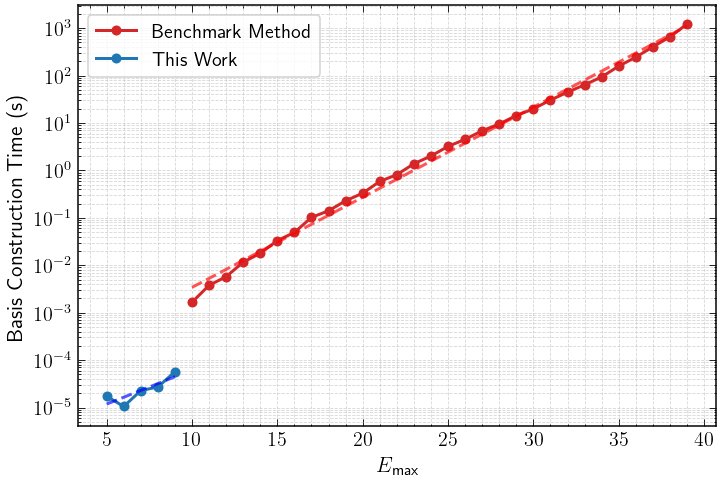

In [3]:
# 1. Importing basis generation timings. 

#This file is produced from the code of https://arxiv.org/abs/2110.08273 and imported here.
csv_filename = "benchmark_basisgen_results.csv"
execution_basisgen_bench = []; emax_basisgen_bench = []
with open(csv_filename, mode="r") as file:
    reader = csv.reader(file)
    
    # Prints Hamiltonian parameters for benchmark. Confirm that these are the same in-use here!
    print('--- Benchmark Params ---')
    print(''.join(next(reader)))
    
    # Skips header for e_max list.
    next(reader) 
    emax_basisgen_bench = list(map(float,next(reader))) #Saves e_max list and converts to float.
    
    next(reader)  # And skips Header for result array.
    for row in reader:
        execution_basisgen_bench.append(float(row[1])) # Convert time back to float
        
        
# This file is produced from the code 'basis_generation_timing.ipynb' and imported here.
csv_filename = "partition_basisgen_results.csv"
execution_basisgen_part = []; emax_basisgen_part = []
with open(csv_filename, mode="r") as file:
    reader = csv.reader(file)
    
    # Prints Hamiltonian parameters for benchmark. Confirm that these are the same in-use here!
    print('--- Partition Params ---')
    print(''.join(next(reader)))
    
    # Skips header for e_max list.
    next(reader) 
    emax_basisgen_part = list(map(float,next(reader))) #Saves e_max list and converts to float.
    
    next(reader)  # And skips Header for result array.
    for row in reader:
        execution_basisgen_part.append(float(row[1])) # Convert time back to float
        


# 2. Linear Fits
startix = 0 # Starting index for the polynomial fit in case it is noisy.
coef_bench = (np.polyfit(emax_basisgen_bench[startix:], np.log10(execution_basisgen_bench)[startix:], 1))
coef_partition = (np.polyfit(emax_basisgen_part[startix:], np.log10(execution_basisgen_part)[startix:], 1))

poly_bench = np.poly1d(coef_bench)
poly_partition = np.poly1d(coef_partition)
xs_bench = np.linspace(emax_basisgen_bench[startix],emax_basisgen_bench[-1])
xs_partition = np.linspace(emax_basisgen_part[startix],emax_basisgen_part[-1])



# 3. Plot the results
fig, ax1 = plt.subplots(figsize=(6, 4))
ax1.set_xlabel(r'$E_\text{max}$', color='black')
ax1.set_ylabel('Basis Construction Time (s)')
ax1.set_yscale('log')
ax1.tick_params(axis='x', labelcolor='black')
ax1.grid(True, which="both", linestyle='--', alpha=0.5)

ax1.plot(emax_basisgen_bench, execution_basisgen_bench, marker ='o', linestyle='-', color='tab:red', label='Benchmark Method')
ax1.plot(
    xs_bench, 10**poly_bench(xs_bench),
    '--', color='r', alpha=0.66
)
ax1.plot(emax_basisgen_part, execution_basisgen_part, marker ='o', linestyle='-', color='tab:blue', label='This Work')
ax1.plot(
    xs_partition, 10**poly_partition(xs_partition),
    '--', color='b', alpha=0.66)
plt.legend()

plt.savefig('basis_construction_comparison.pdf',format='pdf')

## Matrix Construction Timing

### $\phi^2$

--- Benchmark Params ---
mQ = 1.0, mV = 1.0, r = 1.0
--- New Method Params ---
mQ = 1, mV = 1, r = 1
--- Fit Results ---
Benchmark linear fit: (\log_{10} t = 0.17 x +-4.79)
New fit:              (\log_{10} t = 0.15 x +-5.15)


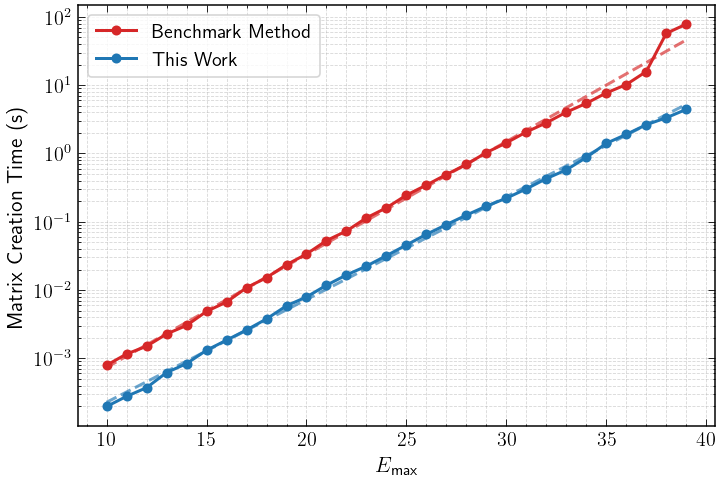

In [4]:
# 1. Parameters for the plot

emax_list = range(10,40) #Test Range of E_max.

# 2. Importing comparison timings. 

#This file is produced from the code 'phi4_truncation.ipynb' and imported here.
benchmark_filename = "phi2_benchmark_results.csv"
execution_times_benchmark = []
with open(benchmark_filename, mode="r") as file:
    reader = csv.reader(file)
    # Prints Hamiltonian parameters for benchmark. Confirm that these are the same in-use here!
    print('--- Benchmark Params ---')
    print(''.join(next(reader)))
            
    # Skips header for e_max list.
    next(reader) 
    emax_list_benchmark = list(map(float,next(reader))) #Saves e_max list and converts to float.
        
    next(reader) # Skips header for timing benchmark
    
    for row in reader:
        # Add data to execution_times_benchmark list.
        execution_times_benchmark.append(float(row[1])) # Convert time back to float

#This file is produced from the code 'CoinHamming_phi2HT.ipynb' and imported here.
statestate_filename = "phi2_statetostate_results.csv"
execution_times_statestate = []
with open(statestate_filename, mode="r") as file:
    reader = csv.reader(file)
    # Prints Hamiltonian parameters for new method. Confirm that these are the same in-use here!
    print('--- New Method Params ---')
    print(''.join(next(reader)))
    
    # Skips header for e_max list.
    next(reader) 
    emax_list_statestate = list(map(float,next(reader))) #Saves e_max list and converts to float.
    
    next(reader) #Skips Header.
    for row in reader:
        # Adds data to execution_times_statestate list.
        execution_times_statestate.append(float(row[1])) # Convert time back to float


# 3. Prepare the Plot
fig, ax1 = plt.subplots(figsize=(6, 4))
ax1.set_xlabel(r'$E_\text{max}$', color='black')
ax1.set_ylabel('Matrix Creation Time (s)')
ax1.set_yscale('log')
ax1.tick_params(axis='x', labelcolor='black')
ax1.grid(True, which="both", linestyle='--', alpha=0.5)


# 4. First degree polynomial fit to the timing data.
startix = 0 # Starting index for the polynomial fit in case it is noisy.
coef_statestate = (np.polyfit(emax_list_statestate[startix:], np.log10(execution_times_statestate)[startix:], 1))
coef_bench = (np.polyfit(emax_list_benchmark[startix:], np.log10(execution_times_benchmark)[startix:], 1))

poly_statestate = np.poly1d(coef_statestate)
poly_bench = np.poly1d(coef_bench)
xs = np.linspace(emax_list[0],emax_list[-1])


# 5. Plots the raw data and linear fits.
# Benchmark method:
ax1.plot(emax_list_benchmark, execution_times_benchmark, marker ='o', linestyle='-', color='tab:red', label='Benchmark Method')
ax1.plot(
    xs, 10**poly_bench(xs),
    '--', color='tab:red', alpha=0.66
)
# State to state method:
ax1.plot(emax_list_statestate, execution_times_statestate, marker='o', linestyle='-', color='tab:blue', label='This Work')
ax1.plot(
    xs, 10**poly_statestate(xs),
    '--', color='tab:blue', alpha=0.66
)


ax1.legend()
plt.savefig('phi2_matrix_creation.pdf',format='pdf')

print('--- Fit Results ---')
print(rf'Benchmark linear fit: (\log_{{10}} t = {coef_bench[0]:.2f} x +{coef_bench[1]:.2f})')
print(rf'New fit:              (\log_{{10}} t = {coef_statestate[0]:.2f} x +{coef_statestate[1]:.2f})')


### $\phi^4$:

--- Benchmark Params ---
mQ = 1, mV = 1, r = 1.0
--- New Method Params ---
mQ = 1.0, mV = 1.0, r = 1.0
--- Fit Results ---
Benchmark linear fit: (\log_{10} t = 0.22 x +-4.02)
New fit:              (\log_{10} t = 0.17 x +-4.54)


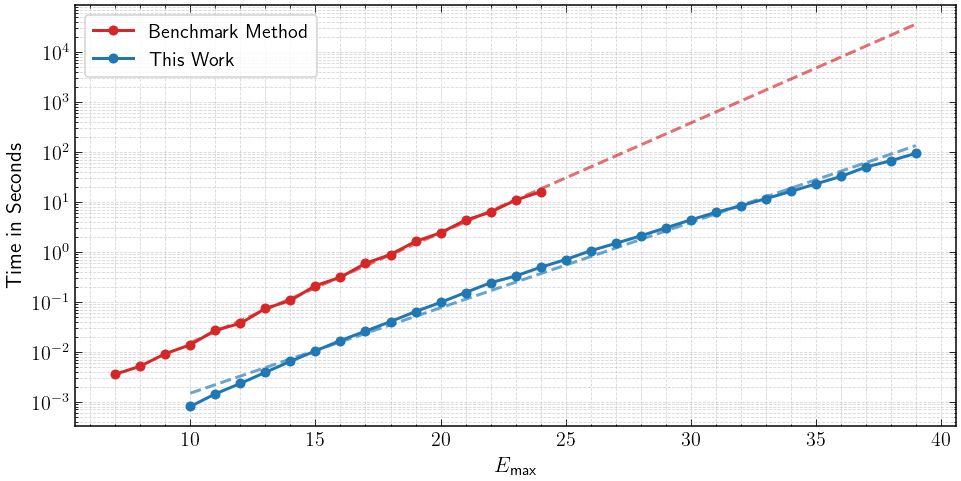

In [5]:
# 1. Parameters for the plot

emax_list = range(10,40) #Test Range of E_max.

# 2. Importing comparison timings. 

#This file is produced from the code 'phi4_truncation.ipynb' and imported here.
benchmark_filename = "LargeRuns/phi4_benchmark_results.csv"
execution_times_benchmark = []
with open(benchmark_filename, mode="r") as file:
    reader = csv.reader(file)
    # Prints Hamiltonian parameters for benchmark. Confirm that these are the same in-use here!
    print('--- Benchmark Params ---')
    print(''.join(next(reader)))
            
    # Skips header for e_max list.
    next(reader) 
    emax_list_benchmark = list(map(float,next(reader))) #Saves e_max list and converts to float.
        
    next(reader) # Skips header for timing benchmark
    
    for row in reader:
        # Add data to execution_times_benchmark list.
        execution_times_benchmark.append(float(row[1])) # Convert time back to float

#This file is produced from the code 'faster_phi4.ipynb' and imported here.
statestate_filename = "LargeRuns/phi4_statetostate_results.csv"
execution_times_statestate = []
with open(statestate_filename, mode="r") as file:
    reader = csv.reader(file)
    # Prints Hamiltonian parameters for new method. Confirm that these are the same in-use here!
    print('--- New Method Params ---')
    print(''.join(next(reader)))
    
    # Skips header for e_max list.
    next(reader) 
    emax_list_statestate = list(map(float,next(reader))) #Saves e_max list and converts to float.
    
    next(reader) #Skips Header.
    for row in reader:
        # Adds data to execution_times_statestate list.
        execution_times_statestate.append(float(row[1])) # Convert time back to float


# 3. Plot the results
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.set_xlabel(r'$E_\text{max}$', color='black')
ax1.set_ylabel('Time in Seconds')
ax1.set_yscale('log')
ax1.tick_params(axis='x', labelcolor='black')
ax1.grid(True, which="both", linestyle='--', alpha=0.5)


# 4. First degree polynomial fit to the timing data.
startix = 0 # Starting index for the polynomial fit in case it is noisy.
coef_statestate = (np.polyfit(emax_list_statestate[startix:], np.log10(execution_times_statestate)[startix:], 1))
coef_bench = (np.polyfit(emax_list_benchmark[startix:], np.log10(execution_times_benchmark)[startix:], 1))

poly_statestate = np.poly1d(coef_statestate)
poly_bench = np.poly1d(coef_bench)
xs = np.linspace(emax_list[0],emax_list[-1])


# 5. Plots the raw data and linear fits.
# Benchmark method:
ax1.plot(emax_list_benchmark, execution_times_benchmark, marker ='o', linestyle='-', color='tab:red', label='Benchmark Method')
ax1.plot(
    xs, 10**poly_bench(xs),
    '--', color='tab:red', alpha=0.66
)
# State to state method:
ax1.plot(emax_list_statestate, execution_times_statestate, marker='o', linestyle='-', color='tab:blue', label='This Work')
ax1.plot(
    xs, 10**poly_statestate(xs),
    '--', color='tab:blue', alpha=0.66
)
ax1.legend()
plt.savefig('phi4_matrix_creation.pdf',format='pdf')

print('--- Fit Results ---')
print(rf'Benchmark linear fit: (\log_{{10}} t = {coef_bench[0]:.2f} x +{coef_bench[1]:.2f})')
print(rf'New fit:              (\log_{{10}} t = {coef_statestate[0]:.2f} x +{coef_statestate[1]:.2f})')



## Summary Plots

### $\phi^2$

In [6]:
# 1. Importing basis generation timings. 

#This file is produced from the code of https://arxiv.org/abs/2110.08273 and imported here.
csv_filename = "LargeRuns/benchmark_basisgen_results.csv"
execution_basisgen_bench = []; emax_basisgen_bench = []
with open(csv_filename, mode="r") as file:
    reader = csv.reader(file)
    
    # Prints Hamiltonian parameters for benchmark. Confirm that these are the same in-use here!
    print('--- Benchmark Basis Generation Params ---')
    print(''.join(next(reader)))
    
    # Skips header for e_max list.
    next(reader) 
    emax_basisgen_bench = list(map(float,next(reader))) #Saves e_max list and converts to float.
    
    next(reader)  # And skips Header for result array.
    for row in reader:
        execution_basisgen_bench.append(float(row[1])) # Convert time back to float
        
        
# This file is produced from the code `basis_generation_timing.ipynb` and imported here.
csv_filename = "LargeRuns/partition_basisgen_results.csv"
execution_basisgen_part = []; emax_basisgen_part = []
with open(csv_filename, mode="r") as file:
    reader = csv.reader(file)
    
    # Prints Hamiltonian parameters for benchmark. Confirm that these are the same in-use here!
    print('--- Partition Params ---')
    print(''.join(next(reader)))
    
    # Skips header for e_max list.
    next(reader) 
    emax_basisgen_part = list(map(float,next(reader))) #Saves e_max list and converts to float.
    
    next(reader)  # And skips Header for result array.
    for row in reader:
        execution_basisgen_part.append(float(row[1])) # Convert time back to float
        

# 2. Importing Transition Matrix Timings

#This file is produced from the code 'phi2_truncation.ipynb' and imported here.
benchmark_filename = "LargeRuns/phi2_benchmark_results.csv"
execution_matrix_bench = []; emax_matrix_bench = []
with open(benchmark_filename, mode="r") as file:
    reader = csv.reader(file)
    # Prints Hamiltonian parameters for benchmark. Confirm that these are the same in-use here!
    print('--- Benchmark Matrix Params ---')
    print(''.join(next(reader)))
            
    # Skips header for e_max list.
    next(reader) 
    emax_matrix_bench = list(map(float,next(reader))) #Saves e_max list and converts to float.
        
    next(reader) # Skips header for timing benchmark
    
    for row in reader:
        # Add data to execution_times_benchmark list.
        execution_matrix_bench.append(float(row[1])) # Convert time back to float

#This file is produced from the code 'phi2_notebook.ipynb' and imported here.
statestate_filename = "LargeRuns/phi2_statetostate_results.csv"
execution_matrix_statestate = []; emax_matrix_statestate = []
with open(statestate_filename, mode="r") as file:
    reader = csv.reader(file)
    # Prints Hamiltonian parameters for new method. Confirm that these are the same in-use here!
    print('--- State to State Params ---')
    print(''.join(next(reader)))
    
    # Skips header for e_max list.
    next(reader) 
    emax_matrix_statestate = list(map(float,next(reader))) #Saves e_max list and converts to float.
    
    next(reader) #Skips Header.
    for row in reader:
        # Adds data to execution_times_statestate list.
        execution_matrix_statestate.append(float(row[1])) # Convert time back to float
        

# 3. Go through both lists and calculate the total.
emax_matrix_bench = np.array(emax_matrix_bench)
emax_basisgen_bench = np.array(emax_basisgen_bench)

ixs, jxs = np.where(emax_matrix_bench[:, None] == emax_basisgen_bench)

total_creation_bench = []; total_emax_bench = []
for ix, jx in zip(ixs, jxs):
    total_creation_bench += [execution_matrix_bench[ix] + execution_basisgen_bench[jx]]
    total_emax_bench += [emax_basisgen_bench[jx]]

emax_matrix_statestate = np.array(emax_matrix_statestate)
emax_basisgen_part = np.array(emax_basisgen_part)

ixs, jxs = np.where(emax_matrix_statestate[:, None] == emax_basisgen_part)
total_creation_statestate = []; total_emax_statestate = []
for ix, jx in zip(ixs, jxs):
    total_creation_statestate += [execution_matrix_statestate[ix] + execution_basisgen_part[jx]]
    total_emax_statestate += [emax_matrix_statestate[ix]]
    

# 4. Importing Diagonalisation Timings
csv_filename = "LargeRuns/phi2_benchmark_diagonalisation.csv"
execution_diagonalisation = []; emax_diagonalisation = []
with open(csv_filename, mode="r") as file:
    reader = csv.reader(file)
    
    # Prints Hamiltonian parameters for benchmark. Confirm that these are the same in-use here!
    print('--- Diagonalisation Params ---')
    print(''.join(next(reader)))
    
    # Skips header for e_max list.
    next(reader) 
    emax_diagonalisation = list(map(float,next(reader))) #Saves e_max list and converts to float.
    
    next(reader)  # And skips Header for result array.
    for row in reader:
        execution_diagonalisation.append(float(row[1])) # Convert time back to float
        


# 5. Linear Fits
startix = 0 # Starting index for the polynomial fit in case it is noisy.
coef_bench = (np.polyfit(total_emax_bench[startix:], np.log10(total_creation_bench)[startix:], 1))
coef_statestate = (np.polyfit(total_emax_statestate[startix:], np.log10(total_creation_statestate)[startix:], 1))
coef_diag = (np.polyfit(emax_diagonalisation[startix:], np.log10(execution_diagonalisation)[startix:], 1))

poly_bench = np.poly1d(coef_bench)
poly_statestate = np.poly1d(coef_statestate)
poly_diag = np.poly1d(coef_diag)
xs_bench = np.linspace(total_emax_bench[startix],total_emax_bench[-1])
xs_statestate = np.linspace(total_emax_statestate[startix],total_emax_statestate[-1])
xs_diag = np.linspace(emax_diagonalisation[startix],emax_diagonalisation[-1])


        

# 5. Plot the results
fig, ax1 = plt.subplots(figsize=(6, 4))
ax1.set_xlabel(r'$E_\text{max}$', color='black')
ax1.set_ylabel('Calculation Time (s)')
ax1.set_yscale('log')
ax1.tick_params(axis='x', labelcolor='black')
ax1.grid(True, which="both", linestyle='--', alpha=0.5)

ax1.plot(total_emax_bench, total_creation_bench, marker ='o', linestyle='-', color='r', label='Matrix Creation for Benchmark Method')
ax1.plot(
    xs_bench, 10**poly_bench(xs_bench),
    '--', color='r', alpha=0.66
)
ax1.plot(total_emax_statestate, total_creation_statestate, marker ='o', linestyle='-', color='b', label='Matrix Creation for This Work')
ax1.plot(
    xs_statestate, 10**poly_statestate(xs_statestate),
    '--', color='b', alpha=0.66
)
ax1.plot(emax_diagonalisation, execution_diagonalisation, marker ='o', linestyle='-', color='g', label='Diagonalisation')
ax1.plot(
    xs_diag, 10**poly_diag(xs_diag),
    '--', color='g', alpha=0.66
)

plt.legend()
plt.savefig('phi2_summary.pdf',format='pdf')


# 6. Print fit results.
print('--- Fit Results ---')
print(rf'Benchmark linear fit: (\log_{{10}} t = {coef_bench[0]:.2f} x +{coef_bench[1]:.2f})')
print(rf'State to State fit:   (\log_{{10}} t = {coef_statestate[0]:.2f} x +{coef_statestate[1]:.2f})')
print(rf'Diagonalisation fit:   (\log_{{10}} t = {coef_diag[0]:.2f} x +{coef_diag[1]:.2f})')

--- Benchmark Params ---
mQ = 1, r = 1.0
--- Partition Params ---
mQ = 1.0, r = 1.0
--- Benchmark Params ---
mQ = 1.0, mV = 1.0, r = 1.0
--- New Method Params ---
mQ = 1, mV = 1, r = 1
--- Partition Params ---
mQ = 1.0, mV = 1.0, r = 1.0


TypeError: expected non-empty vector for x

### $\phi^4$

--- Benchmark Params ---
mQ = 1, r = 1.0
--- Partition Params ---
mQ = 1.0, r = 1.0
--- Benchmark Params ---
mQ = 1, mV = 1, r = 1.0
--- New Method Params ---
mQ = 1.0, mV = 1.0, r = 1.0
--- New Method Params ---
mQ = 1.0, mV = 1.0, r = 1.0
--- Partition Params ---
mQ = 1.0, g = 12.566370614359172, r = 1.0


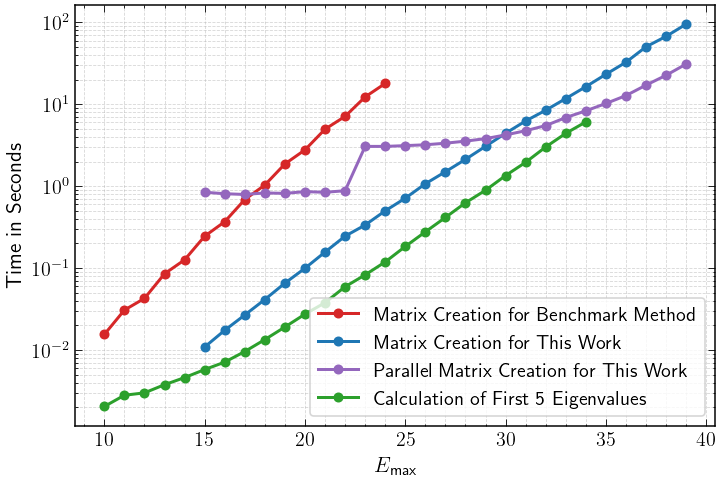

In [ ]:
# 1. Importing basis generation timings. 

#This file is produced from the code of https://arxiv.org/abs/2110.08273 and imported here.
csv_filename = "benchmark_basisgen_results.csv"
execution_basisgen_bench = []; emax_basisgen_bench = []
with open(csv_filename, mode="r") as file:
    reader = csv.reader(file)
    
    # Prints Hamiltonian parameters for benchmark. Confirm that these are the same in-use here!
    print('--- Benchmark Basis Generation Params ---')
    print(''.join(next(reader)))
    
    # Skips header for e_max list.
    next(reader) 
    emax_basisgen_bench = list(map(float,next(reader))) #Saves e_max list and converts to float.
    
    next(reader)  # And skips Header for result array.
    for row in reader:
        execution_basisgen_bench.append(float(row[1])) # Convert time back to float
        
        
# This file is produced from the code `basis_generation_timings.ipynb` and imported here.
csv_filename = "partition_basisgen_results.csv"
execution_basisgen_part = []; emax_basisgen_part = []
with open(csv_filename, mode="r") as file:
    reader = csv.reader(file)
    
    # Prints Hamiltonian parameters for benchmark. Confirm that these are the same in-use here!
    print('--- Partition Params ---')
    print(''.join(next(reader)))
    
    # Skips header for e_max list.
    next(reader) 
    emax_basisgen_part = list(map(float,next(reader))) #Saves e_max list and converts to float.
    
    next(reader)  # And skips Header for result array.
    for row in reader:
        execution_basisgen_part.append(float(row[1])) # Convert time back to float
        

# 2. Importing Transition Matrix Timings

#This file is produced from the code 'phi4_truncation.ipynb' and imported here.
benchmark_filename = "phi4_benchmark_results.csv"
execution_matrix_bench = []; emax_matrix_bench = []
with open(benchmark_filename, mode="r") as file:
    reader = csv.reader(file)
    # Prints Hamiltonian parameters for benchmark. Confirm that these are the same in-use here!
    print('--- Benchmark Matrix Params ---')
    print(''.join(next(reader)))
            
    # Skips header for e_max list.
    next(reader) 
    emax_matrix_bench = list(map(float,next(reader))) #Saves e_max list and converts to float.
        
    next(reader) # Skips header for timing benchmark
    
    for row in reader:
        # Add data to execution_times_benchmark list.
        execution_matrix_bench.append(float(row[1])) # Convert time back to float

#This file is produced from the code 'phi4_notebook.ipynb' and imported here.
statestate_filename = "phi4_statetostate_results.csv"
execution_matrix_statestate = []; emax_matrix_statestate = []
with open(statestate_filename, mode="r") as file:
    reader = csv.reader(file)
    # Prints Hamiltonian parameters for new method. Confirm that these are the same in-use here!
    print('--- State to State Params ---')
    print(''.join(next(reader)))
    
    # Skips header for e_max list.
    next(reader) 
    emax_matrix_statestate = list(map(float,next(reader))) #Saves e_max list and converts to float.
    
    next(reader) #Skips Header.
    for row in reader:
        # Adds data to execution_times_statestate list.
        execution_matrix_statestate.append(float(row[1])) # Convert time back to float
        

#This file is produced from the code 'phi4_parallel_notebook.ipynb' and imported here.
statestate_filename_parallel = "phi4_statetostate_results_parallel.csv"
execution_matrix_parallel = []; emax_matrix_parallel = []
with open(statestate_filename_parallel, mode="r") as file:
    reader = csv.reader(file)
    # Prints Hamiltonian parameters for new method. Confirm that these are the same in-use here!
    print('--- State to State Parallelised Params ---')
    print(''.join(next(reader)))
    
    # Skips header for e_max list.
    next(reader) 
    emax_matrix_parallel = list(map(float,next(reader))) #Saves e_max list and converts to float.
    
    next(reader) #Skips Header.
    for row in reader:
        # Adds data to execution_times_statestate list.
        execution_matrix_parallel.append(float(row[1])) # Convert time back to float
        

# 3. Go through both lists and calculate the total.
emax_matrix_bench = np.array(emax_matrix_bench)
emax_basisgen_bench = np.array(emax_basisgen_bench)

ixs, jxs = np.where(emax_matrix_bench[:, None] == emax_basisgen_bench)

total_creation_bench = []; total_emax_bench = []
for ix, jx in zip(ixs, jxs):
    total_creation_bench += [execution_matrix_bench[ix] + execution_basisgen_bench[jx]]
    total_emax_bench += [emax_basisgen_bench[jx]]

emax_matrix_statestate = np.array(emax_matrix_statestate)
emax_basisgen_part = np.array(emax_basisgen_part)

ixs, jxs = np.where(emax_matrix_statestate[:, None] == emax_basisgen_part)
total_creation_statestate = []; total_emax_statestate = []
for ix, jx in zip(ixs, jxs):
    total_creation_statestate += [execution_matrix_statestate[ix] + execution_basisgen_part[jx]]
    total_emax_statestate += [emax_matrix_statestate[ix]]
    

emax_matrix_parallel = np.array(emax_matrix_parallel)

ixs, jxs = np.where(emax_matrix_parallel[:, None] == emax_basisgen_part)
total_creation_parallel = []; total_emax_parallel = []
for ix, jx in zip(ixs, jxs):
    total_creation_parallel += [execution_matrix_parallel[ix] + execution_basisgen_part[jx]]
    total_emax_parallel += [emax_matrix_parallel[ix]]
    

# 4. Importing Diagonalisation Timings
csv_filename = "phi4_benchmark_diagonalisation.csv"
execution_diagonalisation = []; emax_diagonalisation = []
with open(csv_filename, mode="r") as file:
    reader = csv.reader(file)
    
    # Prints Hamiltonian parameters for benchmark. Confirm that these are the same in-use here!
    print('--- Diagonalisation Params ---')
    print(''.join(next(reader)))
    
    # Skips header for e_max list.
    next(reader) 
    emax_diagonalisation = list(map(float,next(reader))) #Saves e_max list and converts to float.
    
    next(reader)  # And skips Header for result array.
    for row in reader:
        execution_diagonalisation.append(float(row[1])) # Convert time back to float
        

# 5. Plot the results.
fig, ax1 = plt.subplots(figsize=(6, 4))
ax1.set_xlabel(r'$E_\text{max}$', color='black')
ax1.set_ylabel('Calculation Time (s)')
ax1.set_yscale('log')
ax1.tick_params(axis='x', labelcolor='black')
ax1.grid(True, which="both", linestyle='--', alpha=0.5)

ax1.plot(total_emax_bench, total_creation_bench, marker ='o', linestyle='-', color='tab:red', label='Matrix Creation for Benchmark Method')
ax1.plot(total_emax_statestate, total_creation_statestate, marker ='o', linestyle='-', color='tab:blue', label='Matrix Creation for This Work')
ax1.plot(total_emax_parallel, total_creation_parallel, marker ='o', linestyle='-', color='tab:purple', label='Parallel Matrix Creation for This Work')
ax1.plot(emax_diagonalisation, execution_diagonalisation, marker ='o', linestyle='-', color='tab:green', label='Calculation of First 5 Eigenvalues')

plt.legend()

plt.savefig('phi4_summary.pdf',format='pdf')


# 6. Print fit results.
print('--- Fit Results ---')
print(rf'Benchmark linear fit: (\log_{{10}} t = {coef_bench[0]:.2f} x +{coef_bench[1]:.2f})')
print(rf'State to State fit:   (\log_{{10}} t = {coef_statestate[0]:.2f} x +{coef_statestate[1]:.2f})')
print(rf'Diagonalisation fit:   (\log_{{10}} t = {coef_diag[0]:.2f} x +{coef_diag[1]:.2f})')
